In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("DisasterDeclarationsSummaries.csv")

df.head()

,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,...,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id
0,FM-5529-OR,5529,OR,FM,2024-08-09T00:00:00.000Z,2024,Fire,LEE FALLS FIRE,0,0,...,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c
1,FM-5528-OR,5528,OR,FM,2024-08-06T00:00:00.000Z,2024,Fire,ELK LANE FIRE,0,0,...,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac
2,FM-5527-OR,5527,OR,FM,2024-08-02T00:00:00.000Z,2024,Fire,MILE MARKER 132 FIRE,0,0,...,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0
3,DR-4312-CA,4312,CA,DR,2017-05-02T00:00:00.000Z,2017,Severe Storm,FLOODING,0,0,...,60347,Resighini Rancheria (Indian Reservation),17035,NaN,2017041001,9,NaN,2025-03-26T20:21:32.579Z,432a3a64bdbb291ae26cf5a27a33deeabb380481,98a7c5bb-2346-45aa-a1ca-0399440d4f0b
4,DR-4251-AL,4251,AL,DR,2016-01-21T00:00:00.000Z,2016,Severe Storm,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",0,0,...,99001,Autauga (County),16003,NaN,2015122301,4,NaN,2025-03-27T12:21:46.559Z,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3,5229bbae-eee6-42b8-b277-edbafa8d6cb2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69634 entries, 0 to 69633
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   femaDeclarationString     69634 non-null  object
 1   disasterNumber            69634 non-null  int64 
 2   state                     69634 non-null  object
 3   declarationType           69634 non-null  object
 4   declarationDate           69634 non-null  object
 5   fyDeclared                69634 non-null  int64 
 6   incidentType              69634 non-null  object
 7   declarationTitle          69634 non-null  object
 8   ihProgramDeclared         69634 non-null  int64 
 9   iaProgramDeclared         69634 non-null  int64 
 10  paProgramDeclared         69634 non-null  int64 
 11  hmProgramDeclared         69634 non-null  int64 
 12  incidentBeginDate         69634 non-null  object
 13  incidentEndDate           68801 non-null  object
 14  disasterCloseoutDate  

In [4]:
df['declarationDate'] = pd.to_datetime(df['declarationDate'], errors='coerce')

In [5]:
df['year'] = df['declarationDate'].dt.year
df['month'] = df['declarationDate'].dt.month

In [6]:
df[['declarationDate','year','month']].head()

,declarationDate,year,month
0,2024-08-09 00:00:00+00:00,2024,8
1,2024-08-06 00:00:00+00:00,2024,8
2,2024-08-02 00:00:00+00:00,2024,8
3,2017-05-02 00:00:00+00:00,2017,5
4,2016-01-21 00:00:00+00:00,2016,1


In [7]:
df['declarationDate'].isnull().sum()

np.int64(0)

In [8]:
df = df.dropna(subset=['declarationDate'])

In [9]:
yearly_disasters = df.groupby('year').size().reset_index(name='count')

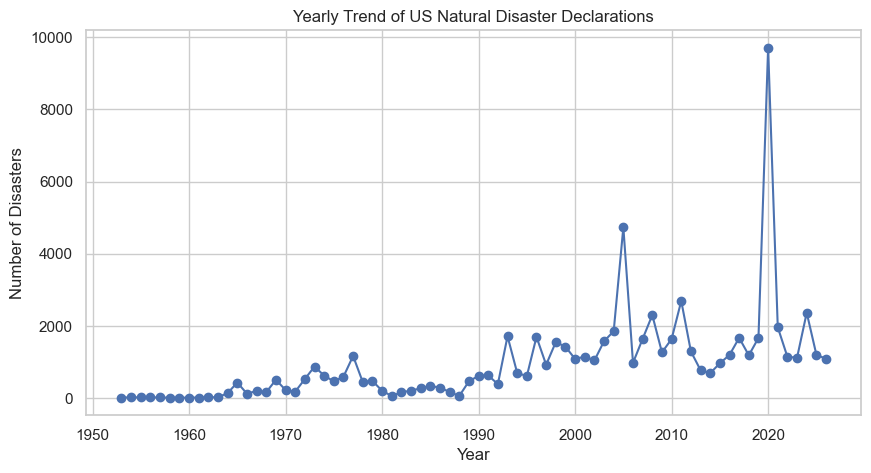

In [10]:
plt.figure(figsize=(10,5))

plt.plot(yearly_disasters['year'], yearly_disasters['count'], marker='o')

plt.title("Yearly Trend of US Natural Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.show()

In [12]:
incident_trends = df.groupby(['year','incidentType']).size().reset_index(name='count')

<Axes: xlabel='year', ylabel='count'>

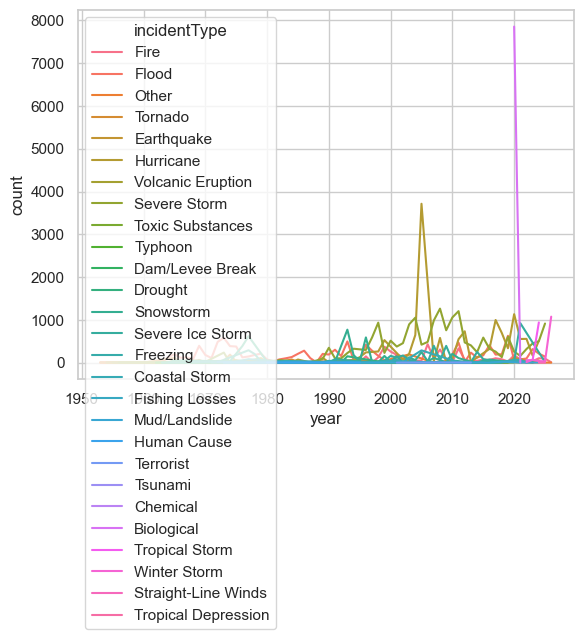

In [13]:
sns.lineplot(data=incident_trends,
             x='year',
             y='count',
             hue='incidentType')

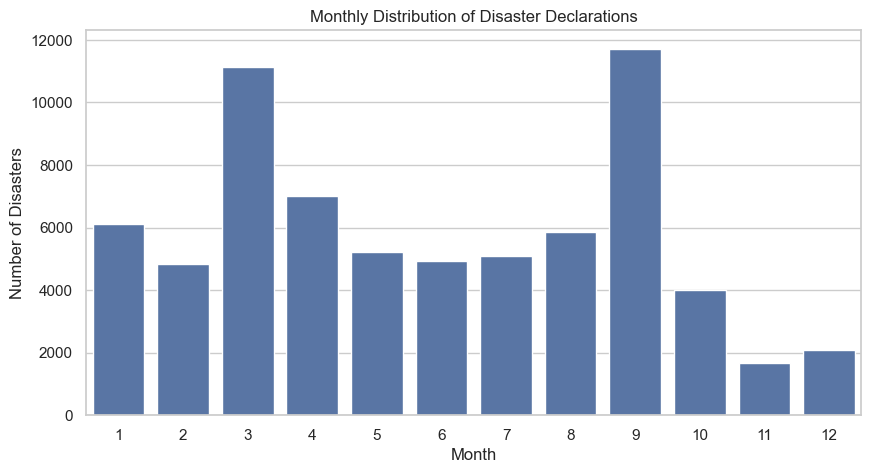

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(data=monthly_trends,
            x='month',
            y='count')

plt.title("Monthly Distribution of Disaster Declarations")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")

plt.show()